In [1]:
# Logistic Regression for Student Mental Health Burnout Prediction

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [16]:
df = pd.read_csv("../data/student_mental_health_burnout.csv")
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [17]:
print(df.shape)
print(df.columns)
print(df.info())
print(df["burnout_level"].value_counts())

(150000, 20)
Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_slee

In [18]:
df = df.drop("student_id", axis=1)

In [19]:
X = df.drop("burnout_level", axis=1)
y = df["burnout_level"]

In [20]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [21]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: Index(['gender', 'course', 'year', 'stress_level', 'sleep_quality',
       'internet_quality'],
      dtype='object')
Numeric: Index(['age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'attendance_percentage', 'cgpa'],
      dtype='object')


In [22]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'attendance_percentage', 'cgpa'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'course', 'year', 'stress_level', 'sleep_quality',
       'internet_quality'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [25]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.3271

Classification Report:
               precision    recall  f1-score   support

        High       0.32      0.28      0.30      9953
         Low       0.33      0.40      0.36     10053
      Medium       0.33      0.31      0.32      9994

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.32     30000
weighted avg       0.33      0.33      0.33     30000


Confusion Matrix:
 [[2744 4002 3207]
 [2921 4010 3122]
 [2845 4090 3059]]


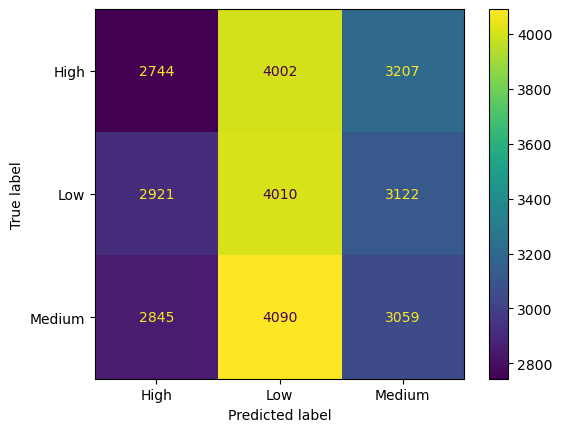

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=label_encoder.classes_)
plt.show()

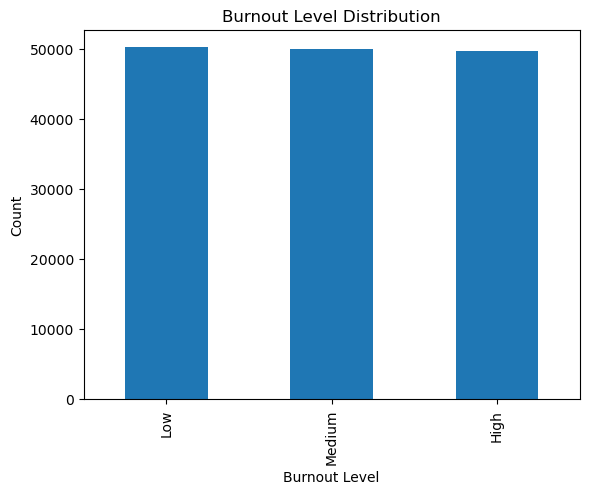

In [27]:
df["burnout_level"].value_counts().plot(kind="bar")
plt.title("Burnout Level Distribution")
plt.xlabel("Burnout Level")
plt.ylabel("Count")
plt.show()